# COVID-19 Data Analysis Report

This notebook explores the Worldometer COVID-19 dataset.  
We clean the data, engineer new features, and visualize insights across countries and continents.

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")


##  1. Load Data
We start by loading the dataset and inspecting its structure.


In [150]:
df = pd.read_csv("worldometer_coronavirus_summary_data.csv")
df.head()
df.info()
df.describe()


FileNotFoundError: [Errno 2] No such file or directory: 'worldometer_coronavirus_summary_data.csv'

## 2. Data Cleaning
We handle missing values to ensure reliable analysis:
- Counts → filled with 0
- Continuous variables → filled with median


In [148]:
df["total_deaths"] = df["total_deaths"].fillna(0)
df["total_deaths_per_1m_population"] = df["total_deaths_per_1m_population"].fillna(0)
df["total_tests"] = df["total_tests"].fillna(0)
df["total_tests_per_1m_population"] = df["total_tests_per_1m_population"].fillna(0)
df["total_recovered"] = df["total_recovered"].fillna(df["total_recovered"].median())
df["active_cases"] = df["active_cases"].fillna(df["active_cases"].median())
df["serious_or_critical"] = df["serious_or_critical"].fillna(df["serious_or_critical"].median())

df.isnull().sum()
#check duplicate
df.duplicated().sum()


np.int64(0)

## 3. Feature Engineering
We create new metrics:
- **Death Rate** = deaths / confirmed × 100
- **Recovery Rate** = recovered / confirmed × 100
- **Risk Level** = categorized into low, medium, high


In [ ]:
df["death_rate"] = np.where(df["total_confirmed"]==0, 0, df["total_deaths"]/df["total_confirmed"])*100
df["recovery_rate"] = (df["total_recovered"]/df["total_confirmed"])*100
df["risk_level"] = pd.cut(df["death_rate"], bins=[0,2,5,100], labels=["low","medium","high"])
df[["country","death_rate","recovery_rate","risk_level"]].head()



## 4. Continent-Level Summaries
We aggregate totals and averages by continent.


In [ ]:
df.groupby("continent").agg({
    "total_deaths":["sum","mean","min"],
    "total_confirmed":["sum","median","max"]
})


## 5. Top Countries
We visualize countries with the highest active cases, deaths, and recoveries.


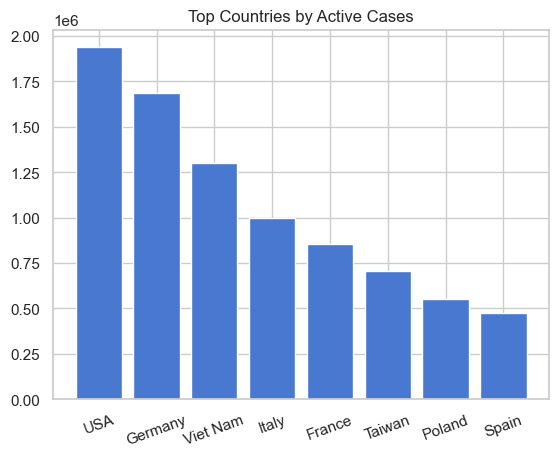

In [149]:
# Active cases
top_active = df.sort_values(by="active_cases", ascending=False).head(8)
plt.bar(top_active["country"], top_active["active_cases"])
plt.title("Top Countries by Active Cases")
plt.xticks(rotation=20)
plt.show()



In [ ]:
#continent by active cases
plt.pie(df_continent["active_cases"], labels=df_continent["continent"], autopct="%1.1f%%")
plt.title("Share of Active Cases by Continent")
plt.show()


In [ ]:
#death
top_death = df.sort_values(by="total_deaths", ascending=False).head(10)
sns.barplot(x="country", y="total_deaths", data=top_death, palette="Reds_r")
plt.title("Top 10 Countries by Total Deaths", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.ylabel("Total Deaths")
plt.show()


In [ ]:
# Recoveries

top_recovery = df.sort_values(by="total_recovered", ascending=False).head(10)
sns.barplot(x="country", y="total_recovered", hue="continent", data=top_recovery, palette="Greens_r")
plt.title("Top Countries by Total Recoveries", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.show()


In [ ]:
#feature engeenering like createing columns like deathrate, recovery rate and risk level
df["death_rate"]=np.where(df["total_confirmed"]==0,0,df["total_deaths"]/df["total_confirmed"])*100
df["recovery_rate"]=(df["total_recovered"]/df["total_confirmed"])*100
df_10=df.sort_values(by="death_rate",ascending=False).head(10)
df["risk_level"] = pd.cut(df["death_rate"], bins=[0,2,5,100], labels=["low","medium","high"])
sns.barplot(x="country",y="death_rate",data=df_10)
plt.title("Top death rate across countries")
plt.xlabel("Country")
plt.ylabel("death rate in %")
plt.xticks(rotation=20)
plt.show()
print(df["death_rate"].head(10))
df["risk_level"].head(10)
df[df["country"]=="Ethiopia"]
df.info()



## 6. Comparisons
Scatterplots show relationships between confirmed cases, deaths, recoveries, and tests.

In [ ]:
sns.scatterplot(x="total_confirmed", y="total_deaths", hue="continent", data=df)
plt.title("Confirmed vs Deaths")
plt.xscale("log")
plt.show()

sns.scatterplot(x="total_confirmed", y="total_recovered", hue="continent", data=df)
plt.title("Confirmed vs Recovered")
plt.show()

sns.scatterplot(x="total_tests", y="total_deaths", hue="continent", data=df)
plt.title("Tests vs Deaths")
plt.show()


## 7. Distributions
Histograms and boxplots reveal skewness in confirmed cases and deaths per million.

In [ ]:
sns.histplot(x="total_confirmed", data=df, bins=10)
plt.title("Distribution of Confirmed Cases")
plt.show()

sns.histplot(x="total_deaths_per_1m_population", data=df, bins=10)
plt.title("Distribution of Deaths per 1M Population")
plt.show()

sns.boxplot(x="total_confirmed", data=df)
plt.title("Boxplot of Confirmed Cases (Log Scale)")
plt.xscale("log")
plt.ylabel("Distribution")
plt.show()
print("Mean for total confirmed",np.mean(df["total_confirmed"]))
print("Median for total confirmed", np.median(df["total_confirmed"]))


## 8. Correlations
Heatmap and pairplot show relationships among numeric variables.

In [ ]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[["total_confirmed","total_deaths","active_cases","continent"]], hue="continent")
plt.show()

In [142]:
print(df[["total_confirmed","total_deaths","total_recovered"]].corr())

                 total_confirmed  total_deaths  total_recovered
total_confirmed         1.000000      0.905811         0.985470
total_deaths            0.905811      1.000000         0.908197
total_recovered         0.985470      0.908197         1.000000


## 9. Conclusion
- Pandemic impact varied widely across regions.  
- Derived metrics (death/recovery rates) provide deeper context than raw counts.  
- Testing volume influences detection and reporting.  
- Visualizations highlight both global patterns and country-specific challenges.  